# Churn Prediction

**Dataset Description**: Churn prediction is the process of analyzing customer behavior to predict when a customer will stop using a product or service. It's a data-driven process that uses historical data, behavioral analytics, and machine learning algorithms to identify customers who are likely to churn.

**About Dataset/Content**: This data set is highly imbalanced and contains details of a bank's customers and the target variable is a binary variable reflecting the fact whether the customer left the bank (closed his account) or he continues to be a customer.


## Imports

In [345]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.utils import resample
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier, VotingClassifier
import xgboost as xgb

from sklearn.tree import DecisionTreeClassifier, plot_tree
# from pgmpy.models import BayesianNetwork
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score

## Data Preprocessing

Missing Values
--------------------
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
--------------------


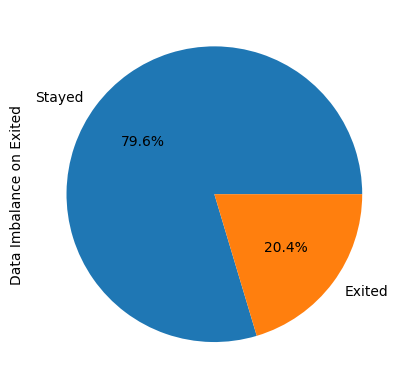

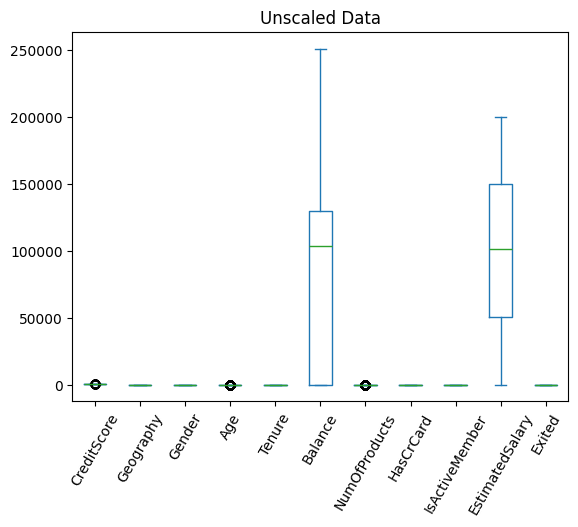

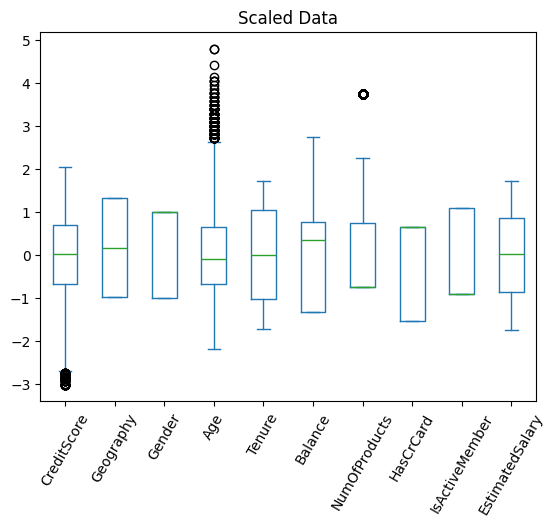

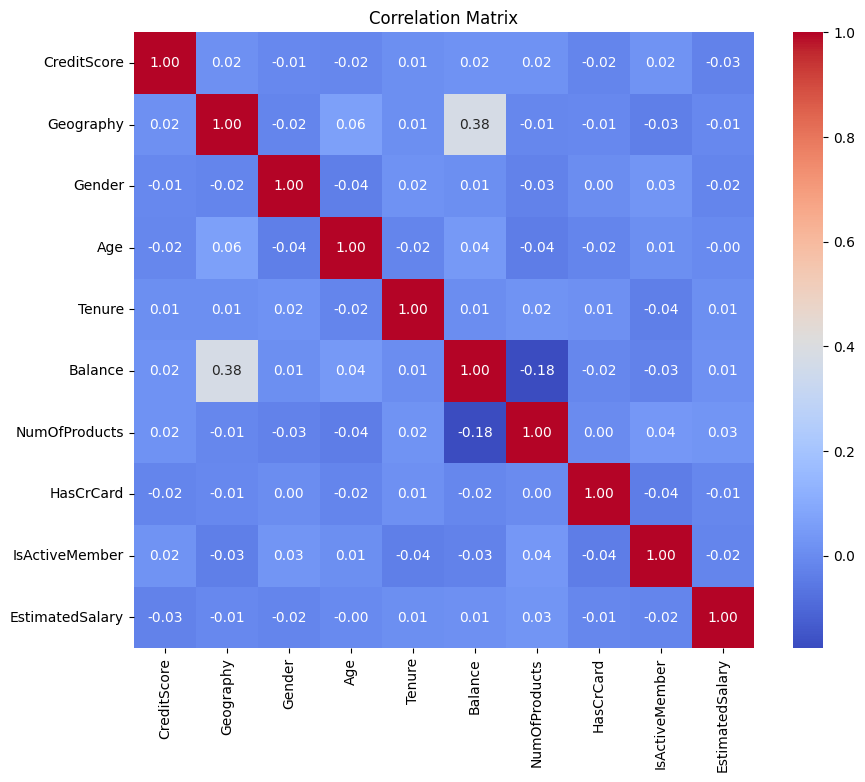

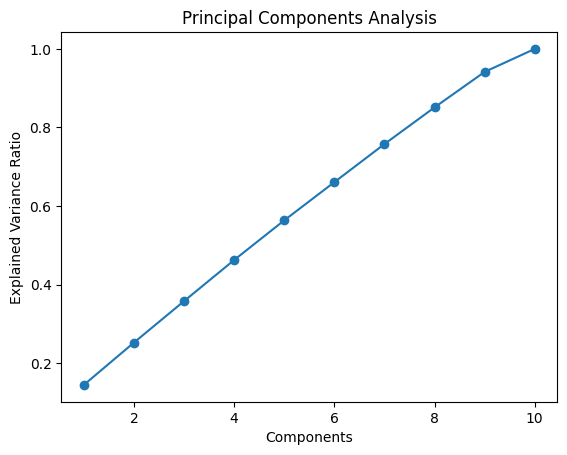

Explained Variance Ratio for each Principal Component:

Component 1: 14.44%
Component 2: 10.77%
Component 3: 10.56%
Component 4: 10.47%
Component 5: 10.10%
Component 6: 9.72%
Component 7: 9.70%
Component 8: 9.34%
Component 9: 9.04%
Component 10: 5.85%

PCA captures 100.00% of the variance with 10 components.


In [346]:
# TODO: Evaluate each model's performance using appropriate metrics (need to carefully select the correct metrics)
# TODO: Consider the removal of the Country label
DATA_FILE_NAME = "Churn_Modelling.csv"
TARGET_COLUMN_NAME = "Exited"
IRRELEVANT_COLUMN_NAMES = ["RowNumber", "CustomerId", "Surname"]
NON_NUMERIC_COLUMN_NAMES = ["Gender", "Geography"]
OUTLIER_COLUMN_NAMES = ["NumOfProducts", "CreditScore", "Age"]
UPDATED_OUTLIER_COLUMN_NAMES = ["NumOfProducts"]
RANDOM_STATE = 123

# TODO: Goal should focus on identifying when customers actually churn
# Class Imbalance needs to be handled properly

def output_missing_values(data_frame):
    # https://stackoverflow.com/questions/59694988/python-pandas-dataframe-find-missing-values
    missing_values = data_frame.isnull().sum()
    print(f"Missing Values")
    print(f"--------------------")
    print(missing_values)
    print(f"--------------------")

def drop_outliers(data_frame):
    # https://stackoverflow.com/questions/23199796/detect-and-exclude-outliers-in-a-pandas-dataframe
    return data_frame[(np.abs(stats.zscore(data_frame[UPDATED_OUTLIER_COLUMN_NAMES])) < 3).all(axis=1)]

def balance_frame_on_target(data_frame):
    """ TODO: Could also consider undersampling customers who stayed. """
    # https://wellsr.com/python/upsampling-and-downsampling-imbalanced-data-in-python/
    data_frame.groupby(TARGET_COLUMN_NAME).size().plot(kind="pie", y=TARGET_COLUMN_NAME, label="Data Imbalance on Exited", labels=['Stayed', 'Exited'], autopct="%1.1f%%")
    data_frame_exited = data_frame[data_frame[TARGET_COLUMN_NAME] == 1]
    data_frame_stayed = data_frame[data_frame[TARGET_COLUMN_NAME] == 0]

    data_frame_exited_upsample = resample(data_frame_exited, replace=True, n_samples=len(data_frame_stayed), random_state=RANDOM_STATE)
    
    data_frame_balanced = pd.concat([data_frame_exited_upsample, data_frame_stayed])

    return data_frame_balanced

def enumerate_categorical_data(data_frame, feature_name):
    """ Convert categorical data to numerical (encode categorical variables). """
    # Track unique values in a column
    value_map = {}
    assigned_number = 0

    # Build a dictionary mapping a column's unique values to numbers
    column = data_frame[feature_name]
    for value in column:
        if value not in value_map:
            value_map[value] = assigned_number
            assigned_number += 1

    # Map column's data to numbers
    # Example: feature_name = Gender, Male becomes 0, Female becomes 1
    data_frame[feature_name] = data_frame[feature_name].map(value_map)

def box_plot_frame(data_frame, title=""):
    data_frame.plot(kind="box")
    plt.title(title)
    plt.xticks(rotation=60)
    plt.show()

def correlation_plot_frame(data_frame):
    """Generates """
    correlation_matrix = data_frame.corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

def analyze_components(data_frame):
    threshold = 0.95

    component_analysis = PCA()
    component_analysis.fit(data_frame)    
    
    def components_to_retain(explained_variance_ratio, threshold):
        cumulative_variance_sums = np.cumsum(explained_variance_ratio)
        
        component_count = len(cumulative_variance_sums)
        for i in range(len(cumulative_variance_sums)):     
            if threshold <= cumulative_variance_sums[i]:   
                component_count = i + 1                    
                break                                      
                
        return component_count   
    
    component_counts = [i for i in range(1, len(np.cumsum(component_analysis.explained_variance_ratio_)) + 1)]
    summed_explained_variance_ratios = np.cumsum(component_analysis.explained_variance_ratio_)
    
    plt.plot(component_counts, summed_explained_variance_ratios, "-o")
    plt.title("Principal Components Analysis")
    plt.xlabel("Components")
    plt.ylabel("Explained Variance Ratio")
    plt.show()
    
    component_count = components_to_retain(component_analysis.explained_variance_ratio_, threshold)   

    n_components_analysis = PCA(n_components=component_count)   
    #n_components_analysis.fit(data_frame)
    # NOTE: Change here to actually apply PCA
    data_frame = n_components_analysis.fit_transform(data_frame)
    
    print("Explained Variance Ratio for each Principal Component:\n")
    for i in range(len(n_components_analysis.explained_variance_ratio_)):    
        print(f"Component {i + 1}: {n_components_analysis.explained_variance_ratio_[i] * 100:.2f}%")

    print("\nPCA captures {:.2f}% of the variance with {} components.".format(sum(n_components_analysis.explained_variance_ratio_) * 100, component_count)) 

# Start Data Preprocessing
data_frame = pd.read_csv(DATA_FILE_NAME)
data_frame = data_frame.drop(columns=IRRELEVANT_COLUMN_NAMES)

output_missing_values(data_frame)

for column_name in NON_NUMERIC_COLUMN_NAMES:
    enumerate_categorical_data(data_frame, column_name)
    
data_frame = balance_frame_on_target(data_frame)
box_plot_frame(data_frame, "Unscaled Data")

"""
TODO:
https://www.datacamp.com/tutorial/normalization-vs-standardization
Normalization: k-NN, Neural Nets
Standardization: Logistic Regression, SVM, PCA
"""
x = data_frame.drop(columns=[TARGET_COLUMN_NAME])
y = data_frame[TARGET_COLUMN_NAME]

scaler = StandardScaler()
scaled_x = scaler.fit_transform(x)

# scaled_x = drop_outliers(scaled_x)

feature_names = data_frame.columns.values # [feature_name for feature_name in data_frame]
feature_names = np.delete(feature_names, -1)
data_frame = pd.DataFrame(data=scaled_x, columns=feature_names)

box_plot_frame(data_frame, "Scaled Data")

correlation_plot_frame(data_frame)

analyze_components(data_frame)

**Breakdown**

Here...

## Model Design and Training

In [347]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8, train_size=0.2)

# Initializes object to be used to remove the mean and scale data to unit variance
sc = StandardScaler()
# Fits the data using the calculated mean and std and standardizes X_train and X_test by via transform
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# Discretizes data to prevent ValueError with classifier
y_train = [ int(y) for y in y_train ]
y_test = [ int(y) for y in y_test ]

def calc_testing_accuracy(model, X_test):
    y_test_pred = model.predict(X_test)
    testing_accuracy = accuracy_score(y_test, y_test_pred)
    return round(testing_accuracy, 5)

def generate_errors(model, X_train, X_test):
    training_errors = []
    testing_errors = []
    
    y_train_pred = model.predict(X_train)
    train_score = accuracy_score(y_train, y_train_pred)
    
    y_test_pred = model.predict(X_test)
    test_score = accuracy_score(y_test, y_test_pred)

    training_errors.append(1 - train_score)
    testing_errors.append(1 - test_score)

    return training_errors, testing_errors

# Tracks best model
estimators = {}

In [348]:
# Tests accuracy of testing sample with default Gaussian Naive
gnb = GaussianNB()
gnb.fit(x_train, y_train)
test_score = calc_testing_accuracy(gnb, x_test)
print(f'Default Naive Bayes Train/Test Accuracy: {test_score:.2%}\n')

estimators['Naive Bayes'] = (gnb, test_score)
print(estimators)

Default Naive Bayes Train/Test Accuracy: 73.83%

{'Naive Bayes': (GaussianNB(), 0.73825)}


In [349]:
# Trains SVC models based on different kernels and tests the accuracy of each regarding the testing sample
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, random_state=1)
    svm.fit(x_train, y_train)
    test_score = calc_testing_accuracy(svm, x_test)

    print(f'{kernel.capitalize()} SVM Accuracy: {test_score:.2%}')
    estimators[f'{kernel}'] = (svm, test_score)

print(estimators)

Linear SVM Accuracy: 71.31%
Poly SVM Accuracy: 77.67%
Rbf SVM Accuracy: 79.33%
Sigmoid SVM Accuracy: 55.51%
{'Naive Bayes': (GaussianNB(), 0.73825), 'linear': (SVC(kernel='linear', random_state=1), 0.71313), 'poly': (SVC(kernel='poly', random_state=1), 0.77671), 'rbf': (SVC(random_state=1), 0.79334), 'sigmoid': (SVC(kernel='sigmoid', random_state=1), 0.55514)}


**Breakdown**

Here...

## Model Improvements
**Hyperparameter Tuning**

Accuracy for ccp_alpha=np.float64(0.0): 79.50%
Accuracy for ccp_alpha=np.float64(0.00015509447523216866): 79.52%
Accuracy for ccp_alpha=np.float64(0.00019934713812264838): 79.51%
Accuracy for ccp_alpha=np.float64(0.00020209675382089158): 79.52%
Accuracy for ccp_alpha=np.float64(0.00020570562442483653): 79.55%
Accuracy for ccp_alpha=np.float64(0.00020604395604395604): 79.57%
Accuracy for ccp_alpha=np.float64(0.00022605965463108325): 79.59%
Accuracy for ccp_alpha=np.float64(0.00023547880690737833): 79.49%
Accuracy for ccp_alpha=np.float64(0.00023547880690737833): 79.49%
Accuracy for ccp_alpha=np.float64(0.0002416990018068184): 79.50%
Accuracy for ccp_alpha=np.float64(0.00024465330587779575): 79.48%
Accuracy for ccp_alpha=np.float64(0.0002511773940345368): 79.49%
Accuracy for ccp_alpha=np.float64(0.00026164311878597594): 79.46%
Accuracy for ccp_alpha=np.float64(0.00026164311878597594): 79.46%
Accuracy for ccp_alpha=np.float64(0.00026164311878597594): 79.46%
Accuracy for ccp_alpha=np.float

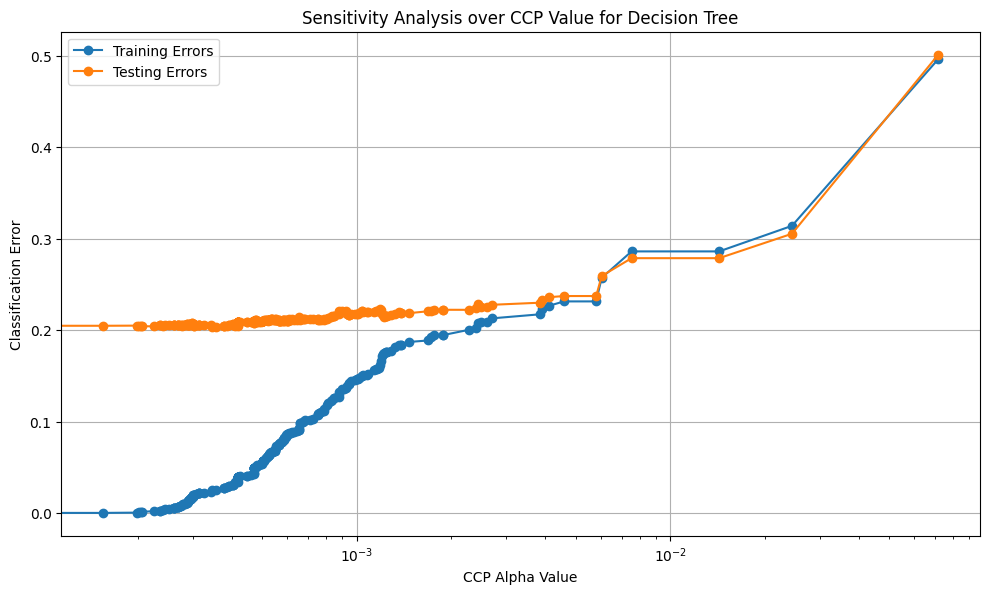

Decision tree test accuracies 49.90% for Max Depth of 1
Decision tree test accuracies 49.90% for Max Depth of 2
Decision tree test accuracies 49.90% for Max Depth of 3
Decision tree test accuracies 49.90% for Max Depth of 4
Decision tree test accuracies 49.90% for Max Depth of 5
Decision tree test accuracies 49.90% for Max Depth of 6
Decision tree test accuracies 49.90% for Max Depth of 7
Decision tree test accuracies 49.90% for Max Depth of 8
Decision tree test accuracies 49.90% for Max Depth of 9
Decision tree test accuracies 49.90% for Max Depth of 10
Decision tree test accuracies 49.90% for Max Depth of 11
Decision tree test accuracies 49.90% for Max Depth of 12
Decision tree test accuracies 49.90% for Max Depth of 13
Decision tree test accuracies 49.90% for Max Depth of 14
Decision tree test accuracies 49.90% for Max Depth of 15
Decision tree test accuracies 49.90% for Max Depth of 16
Decision tree test accuracies 49.90% for Max Depth of 17
Decision tree test accuracies 49.90% for

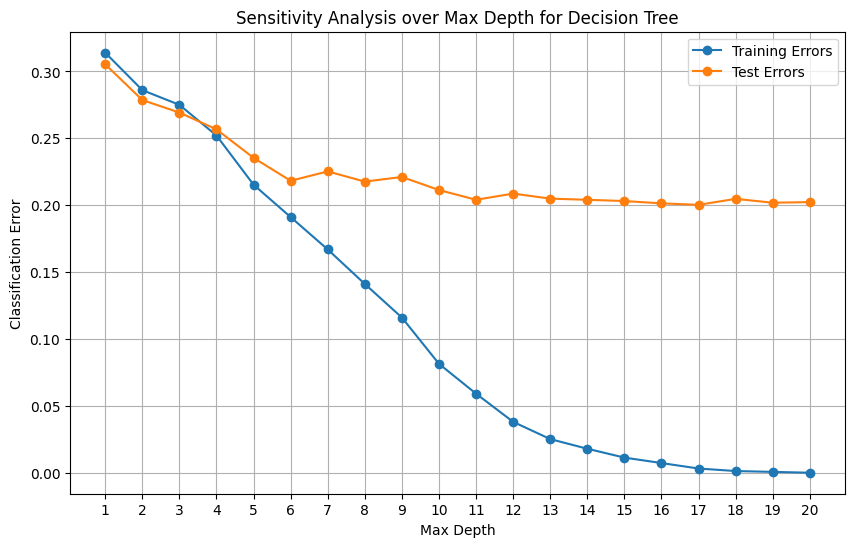

In [350]:
clf = DecisionTreeClassifier(random_state=0)
ccp_path = clf.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = ccp_path.ccp_alphas

# Initialize lists to store accuracy scores
training_errors = []
testing_errors = []
accuracy_scores = []

# Dictionaries to keep track of best hyperparameters


# Iterate over different ccp_alpha values and retrain the decision tree and print out the accuracy of the retrained model
#You code starts here
for ccp_alpha in ccp_alphas:
    pruned_tree = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=0)
    pruned_tree.fit(x_train, y_train)

    training_err, testing_err = generate_errors(pruned_tree, x_train, x_test)
    training_errors.append(training_err[0])
    testing_errors.append(testing_err[0])

    test_score = calc_testing_accuracy(pruned_tree, x_test)

    print(f"Accuracy for {ccp_alpha=}: {test_score * 100:.2f}%") # TODO

plt.figure(figsize=(10, 6))
plt.clf()
plt.plot(ccp_alphas, training_errors, marker='o', label='Training Errors')
plt.plot(ccp_alphas, testing_errors, marker='o', label='Testing Errors')
plt.title('Sensitivity Analysis over CCP Value for Decision Tree')
plt.xlabel('CCP Alpha Value')
plt.ylabel('Classification Error')
plt.grid(True)
plt.tight_layout()
plt.xscale('log')
plt.legend()
plt.show()


# Hypertuning for Max Depth for Decision Tree
max_depth_values = range(1, 21)  # Test max_depth from 1 to 20
training_errors = []
testing_errors = []

for max_depth in max_depth_values:
    # Train a decision tree classifier with the current max_depth value
    tree_model = DecisionTreeClassifier(max_depth=max_depth,
                                        random_state=0)
    tree_model.fit(x_train, y_train)

    # Evaluate the classifier on the training set
    training_err, testing_err = generate_errors(tree_model, x_train, x_test)

    training_errors.append(training_err[0])
    testing_errors.append(testing_err[0])

    print(f'Decision tree test accuracies {test_score:.2%} for Max Depth of {max_depth}')

# Plot the sensitivity analysis results
plt.figure(figsize=(10, 6))
plt.clf()
plt.plot(max_depth_values, training_errors, marker='o', label='Training Errors')
plt.plot(max_depth_values, testing_errors, marker='o', label='Test Errors')
plt.title('Sensitivity Analysis over Max Depth for Decision Tree')
plt.xlabel('Max Depth')
plt.ylabel('Classification Error')
plt.xticks(max_depth_values)
plt.grid(True)
plt.legend()
plt.show()

In [351]:
param_grid = [
    {'max_depth': range(1,21),
     'ccp_alpha': ccp_alphas
    }
]

random_search = RandomizedSearchCV(DecisionTreeClassifier(), param_distributions=param_grid, scoring='accuracy')
random_search.fit(x_train, y_train)
print(f"Best Score: {random_search.best_score_}")
print(f"Best Parameters: {random_search.best_params_}")

estimators['Improved Decision Tree'] = (random_search.best_estimator_, round(random_search.best_score_), 4)


Best Score: 0.7758241758241758
Best Parameters: {'max_depth': 14, 'ccp_alpha': np.float64(0.00040367795469836276)}


Naive Bayes (w/ var_smooth of 1e-08) Test Accuracy: 73.83%
Naive Bayes (w/ var_smooth of 1e-07) Test Accuracy: 73.83%
Naive Bayes (w/ var_smooth of 1e-06) Test Accuracy: 73.83%
Naive Bayes (w/ var_smooth of 1e-05) Test Accuracy: 73.83%
Naive Bayes (w/ var_smooth of 0.0001) Test Accuracy: 73.83%
Naive Bayes (w/ var_smooth of 0.001) Test Accuracy: 73.83%
Naive Bayes (w/ var_smooth of 0.01) Test Accuracy: 73.87%
Naive Bayes (w/ var_smooth of 0.1) Test Accuracy: 73.69%
Naive Bayes (w/ var_smooth of 1) Test Accuracy: 71.81%


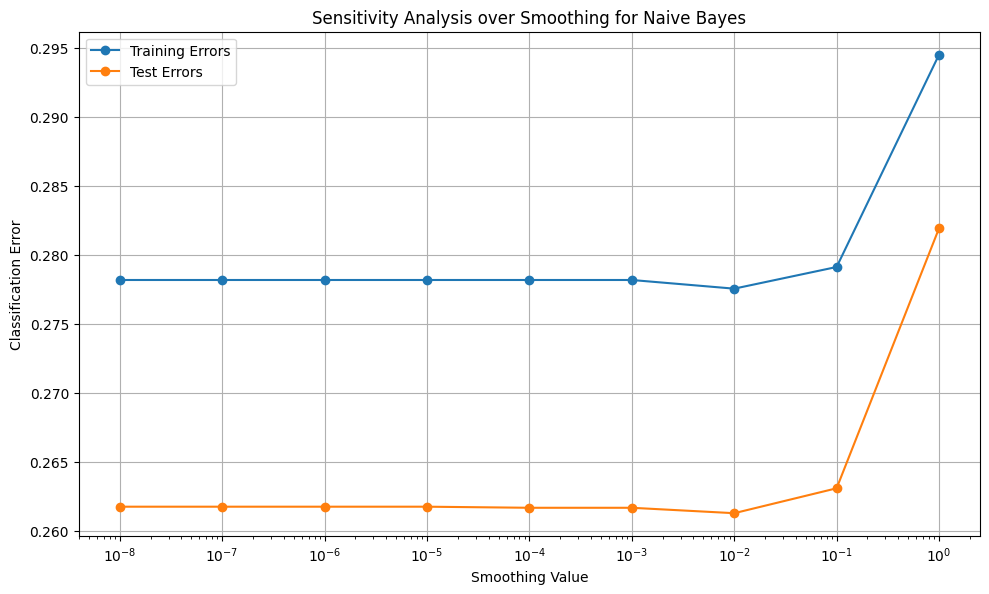

In [352]:
training_errors = []
testing_errors = []
smoothing_values = [ 10**power for power in range(-8, 1, 1) ]

# Tests Gaussian Naive with various var_smoothing values
for smoothing_value in smoothing_values:
    gnb = GaussianNB(var_smoothing = smoothing_value)
    gnb.fit(x_train, y_train)

    training_err, testing_err = generate_errors(gnb, x_train, x_test)

    training_errors.append(training_err[0])
    testing_errors.append(testing_err[0])

    test_score = calc_testing_accuracy(gnb, x_test)

    print(f'Naive Bayes (w/ var_smooth of {smoothing_value}) Test Accuracy: {test_score:.2%}')

# Plot the sensitivity analysis results
plt.figure(figsize=(10, 6))
plt.clf()
plt.plot(smoothing_values, training_errors, marker='o', label='Training Errors')
plt.plot(smoothing_values, testing_errors, marker='o', label='Test Errors')
plt.title('Sensitivity Analysis over Smoothing for Naive Bayes')
plt.xlabel('Smoothing Value')
plt.ylabel('Classification Error')
plt.xticks(smoothing_values)
plt.grid(True)
plt.tight_layout()
plt.xscale('log')
plt.legend()
plt.show()

In [353]:
param_grid = [
    {'var_smoothing': [ 10**power for power in range(-8, 1, 1) ]
    }
]

grid_search = GridSearchCV(gnb, param_grid=param_grid, scoring='accuracy')
grid_search.fit(x_train, y_train)
print(f"Best Score: {grid_search.best_score_:.2%}")
print(f"Best Parameters: {grid_search.best_params_}")

Best Score: 72.18%
Best Parameters: {'var_smoothing': 1e-08}


In [354]:
#pipe_svc = make_pipeline(StandardScaler(), SVC(probability=True, random_state=1))
pipe_svc = make_pipeline(StandardScaler(), SVC(random_state=1))


#param_range = [0.01, 0.1, 1.0, 10.0, 100.0]
param_range = [0.1, 1.0, 10.0]
# TODO: Implement with poly and sigmoid as well? Too long to run when including those however...
param_grid = [
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['linear']},
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['rbf']},
    ]

'''param_grid = [
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['linear']},
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['rbf']},
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['poly']},
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['rbf']},
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['sigmoid']},
    ]'''

grid_search = GridSearchCV(estimator=pipe_svc,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,
                           refit=True,
                           n_jobs=-1)
            
# Carries out a hyperparameter search in order to infer the best combination of parameters for the given SVC model
grid_search.fit(x_train, y_train)
print(f'Best Score: {grid_search.best_score_:.2%}')
print(f'Best Parameters: {grid_search.best_params_}')

estimators['Improved Decision Tree'] = (random_search.best_estimator_, round(grid_search.best_score_, 4))

Best Score: 78.21%
Best Parameters: {'svc__C': 10.0, 'svc__gamma': 1.0, 'svc__kernel': 'rbf'}


## Multi-layer Perceptron

In [355]:
mlp = MLPClassifier(random_state=RANDOM_STATE, max_iter=1000)
mlp.fit(x_train, y_train)

test_score = calc_testing_accuracy(mlp, x_test)

# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
print(f"Multi-layer Perceptron Test Accuracy: {test_score:.2%}")

estimators["MLP"] = (mlp, test_score)
print(estimators)

Multi-layer Perceptron Test Accuracy: 79.63%
{'Naive Bayes': (GaussianNB(), 0.73825), 'linear': (SVC(kernel='linear', random_state=1), 0.71313), 'poly': (SVC(kernel='poly', random_state=1), 0.77671), 'rbf': (SVC(random_state=1), 0.79334), 'sigmoid': (SVC(kernel='sigmoid', random_state=1), 0.55514), 'Improved Decision Tree': (DecisionTreeClassifier(ccp_alpha=np.float64(0.00040367795469836276),
                       max_depth=14), np.float64(0.7821)), 'MLP': (MLPClassifier(max_iter=1000, random_state=123), 0.79633)}


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## Logistic Regression

In [356]:
# TODO
log_regression = LogisticRegression()
log_regression.fit(x_train, y_train)

test_score = calc_testing_accuracy(log_regression, x_test)

print(f"Logistic Regression Test Accuracy: {test_score:.2%}")

estimators["Log Regression"] = (log_regression, test_score)
print(estimators)

Logistic Regression Test Accuracy: 70.56%
{'Naive Bayes': (GaussianNB(), 0.73825), 'linear': (SVC(kernel='linear', random_state=1), 0.71313), 'poly': (SVC(kernel='poly', random_state=1), 0.77671), 'rbf': (SVC(random_state=1), 0.79334), 'sigmoid': (SVC(kernel='sigmoid', random_state=1), 0.55514), 'Improved Decision Tree': (DecisionTreeClassifier(ccp_alpha=np.float64(0.00040367795469836276),
                       max_depth=14), np.float64(0.7821)), 'MLP': (MLPClassifier(max_iter=1000, random_state=123), 0.79633), 'Log Regression': (LogisticRegression(), 0.7056)}


## Ensemble Methods

Training Bagging...

Bagging Evaluation Metrics:
Confusion Matrix:
[[5308 1075]
 [ 962 5396]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6383
           1       0.83      0.85      0.84      6358

    accuracy                           0.84     12741
   macro avg       0.84      0.84      0.84     12741
weighted avg       0.84      0.84      0.84     12741



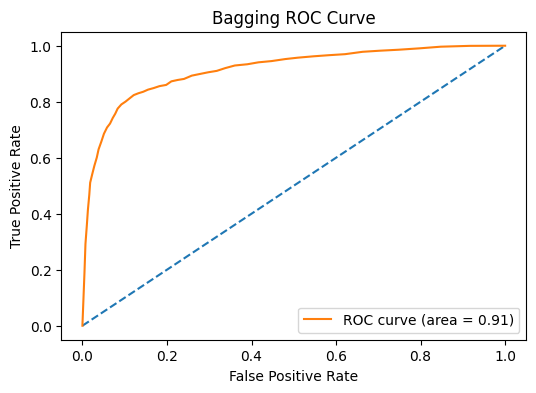

Training AdaBoost...

AdaBoost Evaluation Metrics:
Confusion Matrix:
[[5208 1175]
 [1722 4636]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78      6383
           1       0.80      0.73      0.76      6358

    accuracy                           0.77     12741
   macro avg       0.77      0.77      0.77     12741
weighted avg       0.77      0.77      0.77     12741



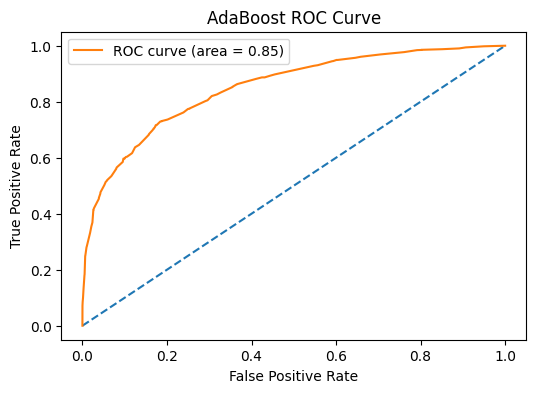

Training Random Forest...

Random Forest Evaluation Metrics:
Confusion Matrix:
[[5439  944]
 [ 981 5377]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      6383
           1       0.85      0.85      0.85      6358

    accuracy                           0.85     12741
   macro avg       0.85      0.85      0.85     12741
weighted avg       0.85      0.85      0.85     12741



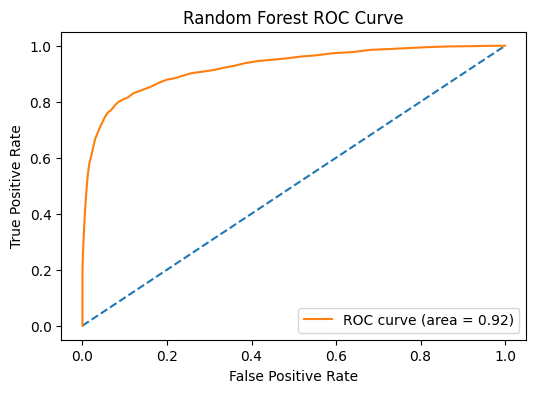

Training XGBoost...

XGBoost Evaluation Metrics:
Confusion Matrix:
[[5300 1083]
 [1085 5273]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      6383
           1       0.83      0.83      0.83      6358

    accuracy                           0.83     12741
   macro avg       0.83      0.83      0.83     12741
weighted avg       0.83      0.83      0.83     12741



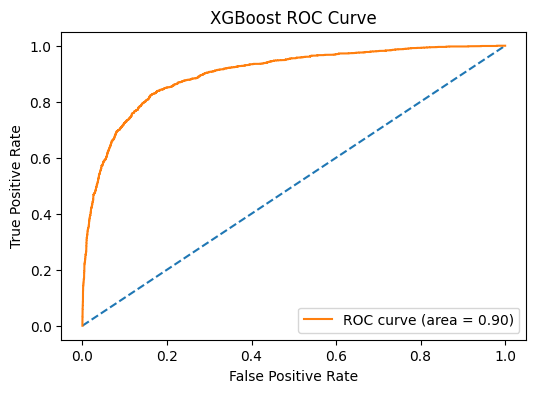

decision_tree.feature_importances_=array([0.10041474, 0.03890714, 0.01460409, 0.26250014, 0.08149648,
       0.17980845, 0.14032597, 0.01091612, 0.04974622, 0.12128065])

Variance Reduction Comparison:
Single Decision Tree - Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79      6383
           1       0.77      0.84      0.81      6358

    accuracy                           0.80     12741
   macro avg       0.80      0.80      0.80     12741
weighted avg       0.80      0.80      0.80     12741


Bagging - Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6383
           1       0.83      0.85      0.84      6358

    accuracy                           0.84     12741
   macro avg       0.84      0.84      0.84     12741
weighted avg       0.84      0.84      0.84     12741


AdaBoost - Classification Report:
              precision    re

In [357]:
classification_reports = {}

classifiers = {
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(n_estimators=50, random_state=RANDOM_STATE)
}

ensembles = {}

for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(x_train, y_train)

    y_predicted = clf.predict(x_test)
    y_predicted_class_probabilities = clf.predict_proba(x_test)
    y_predicted_class_1_probabilities = y_predicted_class_probabilities[:, 1]

    print(f"\n{name} Evaluation Metrics:")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_predicted))
    # TODO, FIX WARNING: https://stackoverflow.com/questions/54150147/classification-report-precision-and-f-score-are-ill-defined
    classification_reports[name] = classification_report(y_test, y_predicted)
    print("\nClassification Report:")
    print(classification_reports[name])

    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_predicted_class_1_probabilities)

    area_under_curve = auc(false_positive_rate, true_positive_rate)

    ensembles[name] = (clf, round(float(area_under_curve), 4))

    plt.figure(figsize=(6, 4))
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(false_positive_rate, true_positive_rate, label=f"ROC curve (area = {area_under_curve:.2f})")
    plt.title(f"{name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

decision_tree = DecisionTreeClassifier()
decision_tree.fit(x_train, y_train)
y_predicted = decision_tree.predict(x_test)

print(f"{decision_tree.feature_importances_=}")

print("\nVariance Reduction Comparison:")
print("Single Decision Tree - Classification Report:")
print(classification_report(y_test, y_predicted))

for name, clf in classifiers.items():
    print(f"\n{name} - Classification Report:")
    print(classification_reports[name])

print(f"\n{ensembles=}")

**Feature Selection**

In [358]:
from sklearn.pipeline import Pipeline

# Apply RFE with logistic regression
rfe = RFE(log_regression)
X_train_rfe = rfe.fit_transform(x_train, y_train)

'''# Get selected feature indices
selected_indices = np.where(rfe.support_)[0]
print(f"{selected_indices=}")
selected_features = [ data_frame.columns[col] for col in selected_indices]

print("Selected features:", selected_features)'''

# Pipeline: RFE + LogisticRegression
pipe_rfe = Pipeline(steps=[
    ('feature_selection', RFE(log_regression)),
    ('logistic_regression', log_regression)
])

# Parameter grid: number of features + logistic regression C hyperparameter
param_grid = {
    'feature_selection__n_features_to_select': range(2, len(data_frame.columns)),
    #'logistic_regression__C': [0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(estimator=pipe_rfe, param_grid=param_grid, scoring='accuracy')
grid_search.fit(x_train, y_train)

# Get the fitted RFE from the best pipeline
best_rfe = grid_search.best_estimator_.named_steps['feature_selection']

# Get the selected feature indices
selected_indices = np.where(best_rfe.support_)[0]
print(f"Selected indices: {selected_indices}")

# Map those indices back to your DataFrame column names
selected_features = [data_frame.columns[idx] for idx in selected_indices]
print("Selected features:", selected_features)

n_features_to_select = grid_search.best_params_['feature_selection__n_features_to_select']
print("Best parameters:", n_features_to_select)
print(f"Best CV accuracy: {grid_search.best_score_:.2%}")

# New training/testing set based on selected features for optimization
x_train_selected = x_train[:, selected_indices]
x_test_selected = x_test[:, selected_indices]

estimators_copy = estimators.copy()
estimators_with_n_features = {}

for name, estimator in estimators_copy.items():
    model, og_accuracy = estimator
    model.fit(x_train_selected, y_train)
    test_score = calc_testing_accuracy(model, x_test_selected)

    print(f"Accuracy for model {model}: {test_score:.2%}")
    
    if og_accuracy < test_score:
        print(f"\tCHANGE OCCURRED with accuracy increase of {test_score - og_accuracy:.2%}!")
        estimators_with_n_features[name] = (model, test_score)

print(f"{estimators=}")
print(f"{estimators_with_n_features=}")

Selected indices: [1 2 3 5 6 7 8]
Selected features: ['Geography', 'Gender', 'Age', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']
Best parameters: 7
Best CV accuracy: 70.11%
Accuracy for model GaussianNB(): 73.79%
Accuracy for model SVC(kernel='linear', random_state=1): 71.09%
Accuracy for model SVC(kernel='poly', random_state=1): 77.47%
Accuracy for model SVC(random_state=1): 78.17%
Accuracy for model SVC(kernel='sigmoid', random_state=1): 53.54%
Accuracy for model DecisionTreeClassifier(ccp_alpha=np.float64(0.00040367795469836276),
                       max_depth=14): 79.34%
	CHANGE OCCURRED with accuracy increase of 1.13%!
Accuracy for model MLPClassifier(max_iter=1000, random_state=123): 78.96%
Accuracy for model LogisticRegression(): 70.62%
	CHANGE OCCURRED with accuracy increase of 0.06%!
estimators={'Naive Bayes': (GaussianNB(), 0.73825), 'linear': (SVC(kernel='linear', random_state=1), 0.71313), 'poly': (SVC(kernel='poly', random_state=1), 0.77671), 'rbf': (SVC(ra

**Model Fusion**

In [366]:
# TODO: Combine best models?
from itertools import combinations

'''estimator_keys = combinations(estimators.keys())

print(estimator_keys)'''
# https://stackoverflow.com/questions/46777181/how-to-tune-weights-in-voting-classifier-sklearn

# Combines models together using 
hybrid_model = VotingClassifier(estimators=[('mlp', estimators['MLP'][0]),
                                            ('dtc', estimators['Improved Decision Tree'][0]),
                                            ('rf', ensembles['Random Forest'][0]),
                                            ],
                                            voting='soft')

param_grid = {'weights':[[1,2,3],[2,1,3],[3,2,1]]}

hybrid_model.fit(x_train, y_train)
test_score = calc_testing_accuracy(hybrid_model, x_test)

print(hybrid_model)
print(f"{test_score=:.2%}")

'''grid_search = GridSearchCV(param_grid = param_grid, estimator=hybrid_model)
grid_search.fit(x_train, y_train)
print(f"{grid_search.best_Score_=}")'''


hybrid_model = VotingClassifier(estimators=[('mlp', estimators_with_n_features['Improved Decision Tree'][0]),
                                            ('dtc', estimators_with_n_features['Log Regression'][0]),
                                            ('rf', ensembles['Random Forest'][0]),
                                            ],
                                            voting='soft')

#param_grid = {'weights':[[1,2,3],[2,1,3],[3,2,1]]}

hybrid_model.fit(x_train_selected, y_train)
test_score = calc_testing_accuracy(hybrid_model, x_test_selected)

print(hybrid_model)
print(f"{test_score=:.2%}")

'''grid_search = GridSearchCV(param_grid = param_grid, estimator=hybrid_model)
grid_search.fit(x_train, y_train)
print(f"{grid_search.best_Score_=}")'''

C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


VotingClassifier(estimators=[('mlp',
                              MLPClassifier(max_iter=1000, random_state=123)),
                             ('dtc',
                              DecisionTreeClassifier(ccp_alpha=np.float64(0.00040367795469836276),
                                                     max_depth=14)),
                             ('rf',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=123))],
                 voting='soft')
test_score=83.31%
VotingClassifier(estimators=[('mlp',
                              DecisionTreeClassifier(ccp_alpha=np.float64(0.00040367795469836276),
                                                     max_depth=14)),
                             ('dtc', LogisticRegression()),
                             ('rf',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=123))],
    

'grid_search = GridSearchCV(param_grid = param_grid, estimator=hybrid_model)\ngrid_search.fit(x_train, y_train)\nprint(f"{grid_search.best_Score_=}")'

**Regularization Techniques**

**Breakdown**

Here...

## Model Comparison and Interpretation

**Breakdown**

Here...